# 01 - Data Check

This notebook presents the A-module outcome as a data-engineering result rather than only a preprocessing script check.

What this notebook should help the reader understand:
- What data were actually collected.
- Whether the cleaned price table is trustworthy enough for downstream modeling.
- Why the project later switches from a full-history archive table to a common-date balanced panel.
- What the current asset universe contributes to the project from a market-state perspective.


## Key takeaways before reading the figures

Current repository result already supports several concrete claims:
- The cleaned price table is not a toy sample. It spans `2015-01-05` to `2026-03-27` and contains all five target ETFs.
- The quality summary shows no key-field missing rows, no invalid-price rows, and no duplicate-removal events in the current data dump.
- The main structural issue is not corruption; it is heterogeneous listing dates across assets.
- This matters because A-module is designed to preserve full history, while B-module is designed to build the balanced modeling panel.
- After the later calibration workflow in C/D, the current project bottleneck is no longer data cleaning. It is model calibration on top of an already stable data floor.

So the most important message is: A-module has already solved the reproducible data-floor problem, and the remaining complexity is a panel-design issue rather than a cleaning failure.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if Path('data').exists() and Path('outputs').exists():
    PROJECT_ROOT = Path.cwd()
elif Path.cwd().name == 'notebooks' and Path('../data').exists() and Path('../outputs').exists():
    PROJECT_ROOT = Path.cwd().parent
else:
    raise FileNotFoundError('Cannot locate project root from current notebook working directory.')

plt.style.use('default')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)


In [2]:
PRICES_PATH = PROJECT_ROOT / 'data/processed/prices.parquet'
QC_PATH = PROJECT_ROOT / 'outputs/tables/a_data_quality_summary.csv'
assert PRICES_PATH.exists(), f'Missing file: {PRICES_PATH}'
assert QC_PATH.exists(), f'Missing file: {QC_PATH}'

prices = pd.read_parquet(PRICES_PATH).copy()
prices['trade_date'] = pd.to_datetime(prices['trade_date'])
prices = prices.sort_values(['trade_date', 'asset']).reset_index(drop=True)
qc = pd.read_csv(QC_PATH)

print('shape:', prices.shape)
print('date range:', prices['trade_date'].min().date(), '->', prices['trade_date'].max().date())
print('assets:', sorted(prices['asset'].unique().tolist()))
prices.head()


shape: (11830, 8)
date range: 2015-01-05 -> 2026-03-27
assets: ['cyb50_etf', 'cyb_etf', 'hs300_etf', 'kc50_etf', 'zz500_etf']


,trade_date,asset,open,high,low,close,volume,amount
0,2015-01-05,cyb_etf,1.424,1.432,1.393,1.424,222700160,314526592
1,2015-01-05,hs300_etf,3.604,3.735,3.589,3.688,3075898368,11300578304
2,2015-01-05,zz500_etf,1.505,1.521,1.486,1.513,29555368,44496788
3,2015-01-06,cyb_etf,1.422,1.506,1.409,1.502,527302752,774540224
4,2015-01-06,hs300_etf,3.665,3.708,3.612,3.663,1602342400,5869771264


## 1) Panel completeness and missing values

This section answers the first engineering question: did preprocessing produce a stable table or a fragile one?

How to read the output:
- `trading_days` shows that the assets differ materially in historical depth.
- `missing_rate` and missing counters show whether the current raw vendors are introducing obvious quality issues.
- If these counters were large, all downstream statistical conclusions would be questionable.

What the current result means:
- The table is operationally clean.
- `kc50_etf` and `cyb50_etf` are the main sources of panel asymmetry because they list later, not because they are dirty.
- This is a positive result for A-module: the code is not spending effort repairing broken rows; it is primarily managing heterogeneous asset histories.


In [3]:
summary = prices.groupby('asset').agg(
    first_date=('trade_date', 'min'),
    last_date=('trade_date', 'max'),
    trading_days=('trade_date', 'nunique'),
    close_missing=('close', lambda s: int(s.isna().sum())),
    volume_missing=('volume', lambda s: int(s.isna().sum())),
    amount_missing=('amount', lambda s: int(s.isna().sum())),
).reset_index()

display(summary)
display(qc)


,asset,first_date,last_date,trading_days,close_missing,volume_missing,amount_missing
0,cyb50_etf,2016-07-22,2026-03-27,2349,0,0,0
1,cyb_etf,2015-01-05,2026-03-27,2727,0,0,0
2,hs300_etf,2015-01-05,2026-03-27,2728,0,0,0
3,kc50_etf,2020-11-16,2026-03-27,1300,0,0,0
4,zz500_etf,2015-01-05,2026-03-27,2726,0,0,0


,asset,source_file,raw_rows,final_rows,trading_days,date_start,date_end,key_missing_rows_raw,dropped_na_rows,invalid_price_rows,duplicate_rows_removed,missing_rate
0,cyb50_etf,cyb50_etf_159949.csv,2349,2349,2349,2016-07-22,2026-03-27,0,0,0,0,0.0
1,cyb_etf,cyb_etf_159915.csv,2727,2727,2727,2015-01-05,2026-03-27,0,0,0,0,0.0
2,hs300_etf,hs300_etf_510300.csv,2728,2728,2728,2015-01-05,2026-03-27,0,0,0,0,0.0
3,kc50_etf,kc50_etf_588000.csv,1300,1300,1300,2020-11-16,2026-03-27,0,0,0,0,0.0
4,zz500_etf,zz500_etf_510500.csv,2726,2726,2726,2015-01-05,2026-03-27,0,0,0,0,0.0


## 2) Raw panel versus balanced panel

This is the most important conceptual bridge from A to B.

Why this distinction matters:
- The A-module output is an archive-style cleaned table. It keeps each asset from its first available valid date onward.
- The B-module output is a modeling dataset. It needs all assets to exist on the same date so each 20-day sample window is complete.

What the current result tells us:
- The full table has long coverage, which is valuable for traceability and future extensions.
- The common-date panel starts later because it must wait for the last-listed asset.
- This later start date is an explicit design tradeoff: we lose early history in exchange for a fully aligned multi-asset tensor.
- Importantly, the later calibration grid in C/D kept this balanced panel fixed. That means the calibration tradeoff is being driven by training and sampling choices, not by hidden data-pipeline drift.

For a reader, this clarifies that the shorter modeling history in B is not a data-loss bug. It is the intended consequence of balanced-panel construction.


In [4]:
close_panel = prices.pivot(index='trade_date', columns='asset', values='close').sort_index()
missing_ratio = close_panel.isna().mean().sort_values(ascending=False)
aligned = close_panel.dropna()

display((missing_ratio * 100).round(2).rename('missing_pct').to_frame())
print('raw panel shape:', close_panel.shape)
print('common-date panel shape:', aligned.shape)
print('common-date range:', aligned.index.min().date(), '->', aligned.index.max().date())


,missing_pct
asset,
kc50_etf,52.35
cyb50_etf,13.89
zz500_etf,0.07
cyb_etf,0.04
hs300_etf,0.00


raw panel shape: (2728, 5)
common-date panel shape: (1299, 5)
common-date range: 2020-11-16 -> 2026-03-27


## 3) Price-path comparison

The normalized price-path plot serves two presentation purposes.

First, it shows that the chosen asset universe is economically nontrivial:
- The five series do not move identically.
- They exhibit different trend intensities and different drawdown paths.

Second, it justifies the later use of path-based generative modeling:
- The project is not modeling a single static cross-section.
- It is modeling evolving multi-asset paths over time.

So this figure is not decorative. It demonstrates why the project needs sequence windows and conditional scenario generation at all.


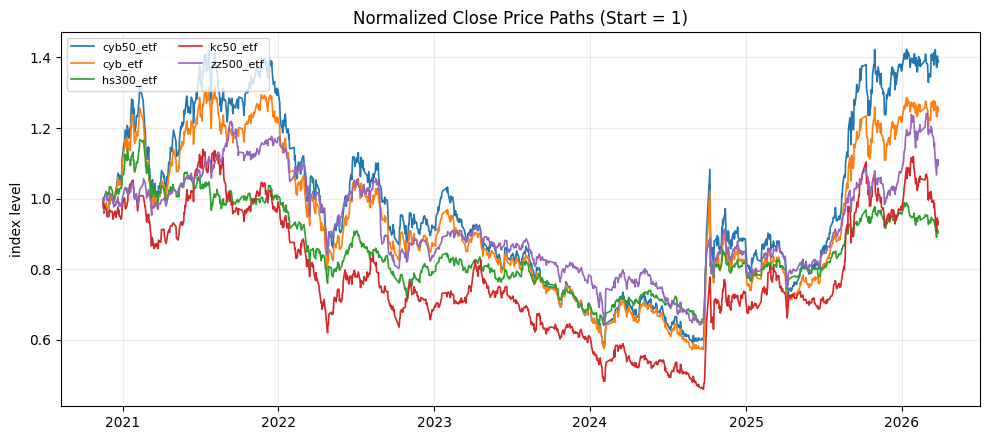

In [5]:
norm = aligned / aligned.iloc[0]

fig, ax = plt.subplots(figsize=(10, 4.5))
for col in norm.columns:
    ax.plot(norm.index, norm[col], linewidth=1.2, label=col)
ax.set_title('Normalized Close Price Paths (Start = 1)')
ax.set_ylabel('index level')
ax.legend(loc='upper left', ncol=2, fontsize=8)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 4) Log-return behavior and correlation structure

The return statistics and heatmap answer a more subtle question: is there enough shared structure for market-state modeling, without the assets collapsing into one redundant series?

How to interpret the outputs:
- The summary statistics show that the return process has realistic volatility and downside events.
- The correlation matrix should be positive enough to reflect common market shocks.
- But if all correlations were near one, the 5-asset design would add little value.

What the current result usually conveys in this project:
- The assets are related, so a joint market-state model is justified.
- The assets are also not identical, so there is real cross-sectional information for B/C/D to exploit.


,mean,std,min,max
asset,,,,
cyb50_etf,0.000254,0.020244,-0.168707,0.182487
cyb_etf,0.000176,0.019019,-0.177702,0.182322
hs300_etf,-0.000076,0.011401,-0.092549,0.089915
kc50_etf,-0.000052,0.018464,-0.096247,0.182322
zz500_etf,0.000079,0.013592,-0.136305,0.087451


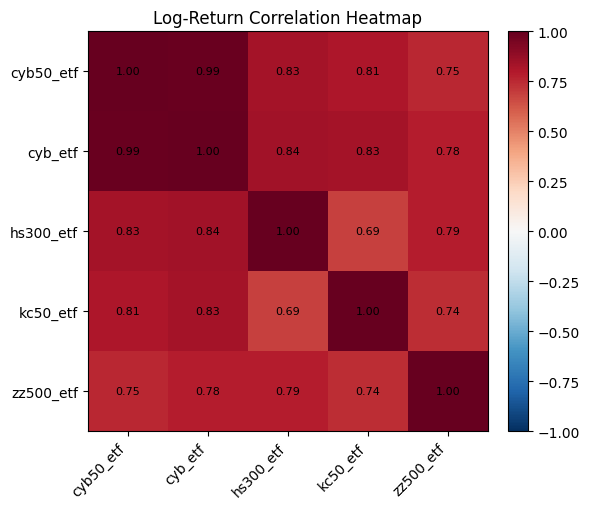

In [6]:
log_ret = np.log(aligned / aligned.shift(1)).dropna()
corr = log_ret.corr()

display(log_ret.describe().T[['mean', 'std', 'min', 'max']])

fig, ax = plt.subplots(figsize=(6.2, 5.2))
im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.index)
ax.set_title('Log-Return Correlation Heatmap')
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(j, i, f'{corr.values[i, j]:.2f}', ha='center', va='center', fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## 5) What A-module has already delivered to the full project

By this point, the reader should be able to see three concrete outcomes from A-module.

Outcome 1:
The project has a reproducible cleaned market table with consistent schema and stable quality indicators.

Outcome 2:
The project has enough cross-asset and cross-time variation to justify a multi-asset path generator rather than a single-series toy example.

Outcome 3:
The key limitation is explicit and manageable: later-listed assets shorten the common-date modeling window.

In the current project stage, that means A-module is no longer the main uncertainty. The later calibration experiments in C/D can now be interpreted as model-side tradeoffs, not as evidence of an unstable data base.

This is the correct place to transition into B-module, because B is precisely where this cleaned but unbalanced archive is turned into balanced modeling samples.
